# Assignment 8: Neural Networks

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Please submit your solution as a Jupyter notebook (.ipynb) and as a PDF created from the (executed) Jupyter notebook.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`) and similarly for the PDF.
- Submit the corresponding files to ILIAS


### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some functions contain typing information (e.g. ``foo: list`` -> the variable ``foo`` is a ``list``). Please make sure your implementation uses the same types in function parameters and return values. For more information take a look at the at the [python typing documention](https://mypy.readthedocs.io/en/stable/).
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!
- <span style="color:green">**Hint**</span>: Make sure you do not accidentally train a network twice by running a code cell twice. To make sure this did not happen, restart the kernel when you are done with the assignment and click Run All before you export the PDF.

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements from the first assignment via ```python3 -m pip install -r requirements.txt```. *Do not use any additional python packages*.

Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. The following imports should not throw any errors:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import List, Tuple
from time import time
from copy import deepcopy
%matplotlib inline

---
<span style="color:red">Please also include your name and matriculation number here:

---
# Lecture slides with relevant material

In this assignment you will implement an artificial neural network (ANN) with a customizable number of layers and train it with backpropagation. The relevant part of the slides is therefore the section __Artificial Neural Networks__ explaining the forward an backward pass in an ANN.

# A remark about batch matrix multiplication

Consider the matrix multiplication $W \cdot x$ with the input column vector $x \in \mathbb{R}^{m \times 1}$ where $m$ denotes the number of input features. When performing gradient descent, we have to do this computation for every element in a (mini-)batch.

While it is possible to use a for loop to do these matrix multiplications sequentially, it is vastly more efficient to parallelelize over datapoints. This is called batch matrix multiplication.

To this end, we can combine all elements of a (mini-)batch into a single matrix $x \in \mathbb{R}^{N \times m}$ ($N$ being the number of datapoints). The batch matrix multiplication then looks like this: $z = x \cdot W^T \in \mathbb{R}^{N \times N_\text{units}}$ with $N_\text{units}$ denoting the number of units in the first layer. The first dimension of $x$ and $z$ is reffered to as __batch dimension__ and corresponds to the datapoints.

We strongly encourage you to get acquainted with how such __vectorization__ can speed up code. The example below illustrates that this is already the case for numpy on CPU. The differences become even bigger with deep learning libraries running on GPU.

<span style="color:green">**Hint**</span>: Some useful numpy functions are ``np.sum`` and ``np.matmul``. If you are a physicist, you might love ``np.einsum`` ;-)

You can also solve the assignment with for loops but the code will be slow and we will subtract 3 points.

In [2]:
# Time sequential and vectorized matrix multiplication
W = np.random.randn(100, 100)
x = np.random.randn(1000, 100)
time0 = time()
z_sequential = np.zeros((1000, 100))
for i in range(1000):
    z = np.dot(W, x[i])
time1 = time()
z_parallel = np.matmul(x, W.T)
time2 = time()
print(f"Time for sequential matrix multiplication: {time1 - time0}")
print(f"Time for parallel matrix multiplication: {time2 - time1}")

Time for sequential matrix multiplication: 0.010215282440185547
Time for parallel matrix multiplication: 0.0025131702423095703


---
## Data generation

In this coding assignment, you will implement a multilayer perceptron (MLP), i.e., a feedforward neural network with fully connected neurons, and train it on two regression datasets.

We use a toy dataset that is easy to visualize: A superposition of sinusoidal waves (1D input, 1D output). The MLP you will implement can be successfully applied to more complex data though.

In [3]:
n_datapoints = 300
np.random.seed(0)
X = np.random.rand(n_datapoints, 1)
def f(input):
    return np.sin(2*np.pi*input[:,0])+1*np.cos(4*np.pi*input[:,0])
Y = f(X)
# insert output dimension
Y = Y[:, None]

Plotting the data:

Text(0, 0.5, 'Y')

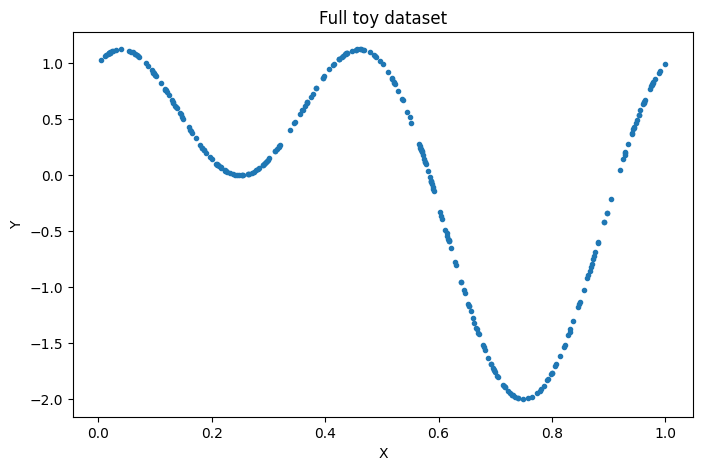

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(X[:, 0], Y[:, 0], ".")
ax.set_title("Full toy dataset")
ax.set_xlabel("X")
ax.set_ylabel("Y")

In [5]:
print("Shape of X: ", X.shape)
print("Shape of Y: ", Y.shape)

Shape of X:  (300, 1)
Shape of Y:  (300, 1)


Split data into train and test set:

In [6]:
# The function name reffers to splitting into trian and test set but we will view 
# the second set as a validation set.
X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.1, random_state=1)

In [7]:
print(X_train.shape, X_valid.shape)
print(Y_train.shape, Y_valid.shape)

(270, 1) (30, 1)
(270, 1) (30, 1)


### <span style="color:red">[TODO]</span> Implementing the MLP (8 pts)

In this part of the exercise you implement the forward and backward passes of the MLP. Make sure to read the `__init__` method and the comments as they contain hints.

In [8]:
# The action functions and their derivatives are defined as lambda functions for brevity.
# A lambda function is like an anonymous function in Python. Instead of writing 
# def function_name(x): return x**2, you can write function_name = lambda x: x**2.
act_fun_map = {
    "id" : (lambda x: x),
    "relu" : (lambda x: np.maximum(0.0, x)),
    "tanh" : (lambda x: np.tanh(x))
}
act_fun_derivative_map = {
    "id" : (lambda x: 1),
    "relu" : (lambda x: np.sign(np.maximum(0.0, x))),
    "tanh" : (lambda x: (1 - np.tanh(x)**2))
}

class Layer:
    """A layer of an MLP.
    
    We use this to store the weights and biases of a layer, as well as intermediate values during the forward pass.
    
    During the backward pass, the gradients w.r.t. the weights and biases are also stored in this object."""

    def __init__(self, num_units: int, dim_in: int, act_fun_name: str):
        """Initialize the layer with random weights and biases.
        
        Args:
            num_units: The number of units in the layer.
            dim_in: The dimension of the input data.
            act_fun_name: The name of the activation function.
        """
        self.num_units = num_units
        self.act_fun = act_fun_map[act_fun_name]
        self.act_fun_deriv = act_fun_derivative_map[act_fun_name]
        if act_fun_name in ["id", "tanh"]:
            # Xavier initialization
            weight_variance = 2.0 / (num_units + dim_in)
        elif act_fun_name == "relu":
            # He initialization
            weight_variance = 2.0 / dim_in
        # the weight matrix of a layer with num_units neurons has shape (num_units, dim_in)
        # so the rows are the weights of a single neuron
        self.W = np.random.randn(num_units, dim_in) * np.sqrt(weight_variance)
        self.b = np.zeros(num_units)

        # intermediate values stored during forward pass
        self.x = None # input values
        self.z = None # layer values before activation function
        self.a = None # layer activation (after activation function)

        # gradients w.r.t weights and biases
        self.grad_W = None
        self.grad_b = None


class MLP:

    def __init__(self, input_dim: int, layer_param_lst: List[Tuple], seed: int = 2):        
        """Initialize the MLP with random weights and biases.
        
        Args:
            input_dim: The dimension of the input data.
            layer_param_lst: A list of tuples, where each tuple contains the number of units in the layer and the activation function name.
                [(num_units, activation function name)]
            seed: Random seed for reproducibility.
        """
        # layers
        self.layer_lst = []

        # initialize weight matrices and bias vectors
        np.random.seed(seed)
        dim_in = input_dim
        for (num_units, act_fun_name) in layer_param_lst:
            layer = Layer(num_units, dim_in, act_fun_name)
            self.layer_lst.append(layer)
            dim_in = num_units
        
    def forward(self, x: np.ndarray) -> np.ndarray:         
        """Evaluate the MLP on a batch of inputs (forward pass).
        
        Args:
            x: A batch of inputs. Shape: (batch_size, input_dim)
        Returns:
            The output of the MLP. Shape: (batch_size, num_units_output_layer)
        """
        # Hint: Don't forget to store the intermediate values for the backward pass.
        ### BEGIN SOLUTION
        for layer in self.layer_lst:
            layer.x = x
            layer.z = np.matmul(x, layer.W.T) + layer.b
            layer.a = layer.act_fun(layer.z)
            x = layer.a
        return x
        ### END SOLUTION

    def backward(self, delta: np.ndarray):
        """Backpropagate the error through the network (backward pass).
        
        Args:
            delta: The derivative of the loss function with respect to the output of the network.
                Shape: (batch_size, num_units_output_layer). In our case, this is simply the error.
        """
        # Hint: Think about in which order you have to traverse the layers in the BACKWARD pass.
        # Also remember that you should have stored intermediate values during the forward pass.
        ### BEGIN SOLUTION
        for layer in reversed(self.layer_lst):
            # differentiate through activation function
            delta = delta * layer.act_fun_deriv(layer.z)
            # compute gradients
            layer.grad_W = np.matmul(delta.T, layer.x)
            layer.grad_b = np.sum(delta, axis=0)
            # delta of previous layer
            delta = np.matmul(delta, layer.W)
        ### END SOLUTION

    def train_with_square_loss(self, X: np.ndarray, y: np.ndarray, eta=0.001):
        """One step of gradient descent on a (mini-)batch, using the mean squared loss.
        
        Args:
            X: A batch of inputs. Shape: (batch_size, input_dim)
            y: The corresponding batch of targets. Shape: (batch_size, num_units_output_layer)
            eta: The step size for the gradient descent step."""
        pred = self.forward(X)
        # loss function: L = 1/2 * np.sum((pred - y)**2) / X.shape[0]
        delta = (pred - y) / X.shape[0]
        self.backward(delta)

        # gradient descent update
        for layer in self.layer_lst:
            # Update the parameters of the layer
            # TODO: Change epsilon to eta
            ### BEGIN SOLUTION
            layer.W -= eta * layer.grad_W
            layer.b -= eta * layer.grad_b
            ### END SOLUTION
            
        # return current error
        return np.mean((pred - y)**2)     
        
    def error(self, X, y):
        pred = self.forward(X)
        return 0.5 * np.mean((pred - y)**2)
        

Set up an MLP with one hidden layer of 50 units. Use ReLU as activation function.

In [9]:
net = MLP(
    input_dim=X_train.shape[1],
    layer_param_lst=[(32, "tanh"), (32, "relu"), (32, "relu"), (1, "id")],
)

In [10]:
assert np.abs(net.error(X_train, Y_train) - 0.5365) < 1e-4
assert np.abs(net.error(X_valid, Y_valid) - 0.2237) < 1e-4
assert net.forward(X_train).shape == (270, 1)
assert net.forward(X_valid).shape == (30, 1)
### BEGIN HIDDEN TESTS
# Their results might vary slightly if they implemented the network in a different way.
# In that case look at their code and judge if their implementation is correct.
assert np.abs(net.forward(np.array([[0.21]])) - 0.0477) < 1e-4
## END HIDDEN TESTS

## Perform training using batch gradient descent (using all of the training data at once)

In [11]:
train_error_lst = []
valid_error_lst = []
batch_checkpoints = []

In [12]:
n_steps = 20000
batch_times = []
time_start = time()
for i in range(n_steps):    
    train_error = net.train_with_square_loss(X_train, Y_train, 0.02)
    valid_error = net.error(X_valid, Y_valid)
    train_error_lst.append(train_error)
    valid_error_lst.append(valid_error)
    batch_times.append(time() - time_start)
    if i % 1000 == 0:
        print (f"Training step {i}; training error: {train_error}; validation error: {valid_error}")
        batch_checkpoints.append(deepcopy(net))

Training step 0; training error: 1.073023291338991; validation error: 0.22380017878393554
Training step 1000; training error: 0.5118010203239807; validation error: 0.24127247374869978
Training step 2000; training error: 0.08145086118209192; validation error: 0.04482280639447519
Training step 3000; training error: 0.004522955978196297; validation error: 0.002802877443475868
Training step 4000; training error: 0.0016448902247668982; validation error: 0.0009544993893630786
Training step 5000; training error: 0.001104879652397171; validation error: 0.0005494547780552352
Training step 6000; training error: 0.0009575443669579867; validation error: 0.00040811063256093066
Training step 7000; training error: 0.0008829208348147431; validation error: 0.0003542629496076291
Training step 8000; training error: 0.0008273867632071952; validation error: 0.0003283205603605806
Training step 9000; training error: 0.0007805645942753083; validation error: 0.00031401055682130693
Training step 10000; training

Plot training curve.

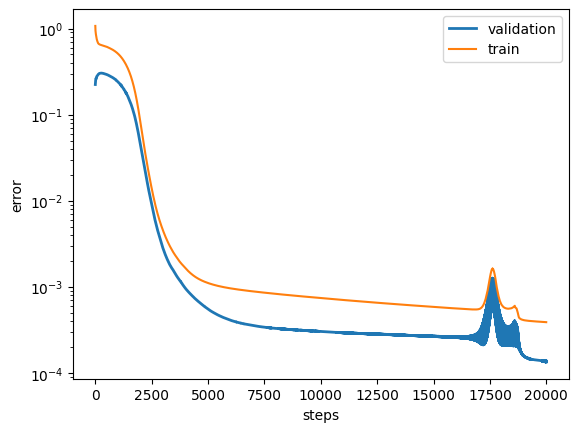

In [13]:
# With training steps on the x axis
plt.plot(valid_error_lst, linewidth=2, label="validation")
plt.plot(train_error_lst, label="train")
plt.yscale("log")
plt.xlabel("steps")
plt.ylabel("error")
plt.legend()
plt.show()

In [14]:
print("Final loss on the training set: ", net.error(X_train, Y_train))
print("Final loss on the validation set: ", net.error(X_valid, Y_valid))

Final loss on the training set:  0.0001939024567132899
Final loss on the validation set:  0.0001338838788701099


In [15]:
def plot_predictions(net, X_train, Y_train, X_valid, Y_valid, title, output_path=None):
    """Plot MLP predictions alongside data.
    
    Args:
        net: The MLP model.
        X: The input data.
        Y: The target data.
        ax: The matplotlib axis to plot on.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    X_uniform = np.linspace(0, 1, 200).reshape(-1, 1)
    ax.plot(X_uniform, net.forward(X_uniform)[:, 0], "-", label="prediction", color="C1")
    # Plotting the actual data
    ax.plot(X_train[:, 0], Y_train[:, 0], ".", label="data")

    # Plotting the predictions at the validation data
    ax.plot(X_valid[:, 0], net.forward(X_valid)[:, 0], ".", label="prediction on validation set", color="C2")

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    if output_path is not None:
        plt.savefig(output_path)
        plt.close()

Plot the predictions together with the data. Also check out the learning progress as depicted in the PNGs written to this directory.

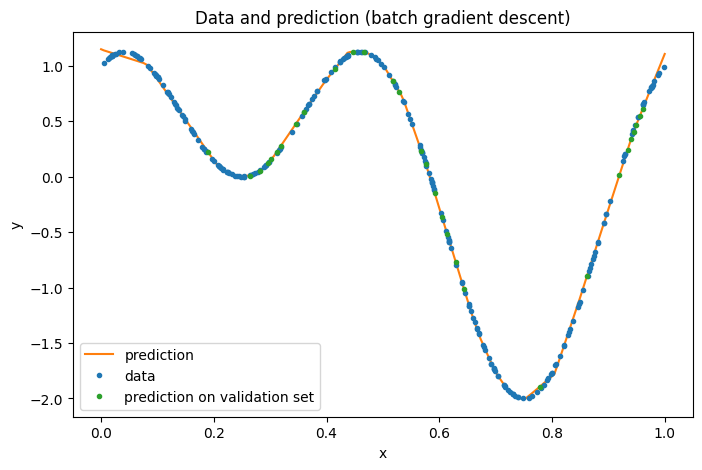

In [16]:
for i, cp in enumerate(batch_checkpoints):
    plot_predictions(
        net=cp,
        X_train=X_train,
        Y_train=Y_train,
        X_valid=X_valid,
        Y_valid=Y_valid,
        title="Data and prediction (batch gradient descent)",
        output_path=f"checkpoint_{i}.png"
    )
plot_predictions(
    net=cp,
    X_train=X_train,
    Y_train=Y_train,
    X_valid=X_valid,
    Y_valid=Y_valid,
    title="Data and prediction (batch gradient descent)",
)

Your validation loss might have been lower than your training loss. After looking at the plot above, can you guess why this happens?

### <span style="color:red">[TODO]</span> Stochastic gradient descent (4 pts)

In [17]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

In [18]:
net_mb = MLP(
    input_dim=X_train.shape[1],
    layer_param_lst=[(32, "tanh"), (32, "relu"), (32, "relu"), (1, "id")],
)

In [19]:
def sample_minibatch(X: np.ndarray, Y: np.ndarray, batch_size: int):
    """Sample a minibatch from the datset.
    
    The minibatch should be randomly sampled with replacement,
    i.e., uniformly from dataset.
    
    Args:
        X: The input data. Shape: (n_datapoints, input_dim)
        Y: The target values. Shape: (n_datapoints, 1)
        batch_size: The number of samples in the minibatch.
    Returns:
        A tuple (X_batch, Y_batch) containing the input and target values of the minibatch.
        """
    ### BEGIN SOLUTION
    ids = np.random.randint(low=0, high=X.shape[0], size=batch_size)
    return X[ids], Y[ids]
    ### END SOLUTION

In [20]:
batch_size = 32
batches_per_epoch = X_train.shape[0] // batch_size

In [21]:
n_epochs = 20000
train_sgd_error_lst = []
valid_sgd_error_lst = []
train_sgd_minibatch_errors = []
minibatch_times = []
minibatch_checkpoints = []
time_start = time()
for i in range(n_epochs):
    for j in range(batches_per_epoch):        
        # Sample a minibatch and do one gradient descent step with it
        # Store the resulting training error in train_minibatch_error
        ### BEGIN SOLUTION
        X_minibatch, Y_minibatch = sample_minibatch(X, Y, batch_size)
        train_minibatch_error = net_mb.train_with_square_loss(X_minibatch, Y_minibatch, 0.02)
        ### END SOLUTION
        train_sgd_minibatch_errors.append(train_minibatch_error)
    
    train_error = net_mb.error(X_train, Y_train)
    train_sgd_error_lst.append(train_error)
    valid_error = net_mb.error(X_valid, Y_valid)
    valid_sgd_error_lst.append(valid_error)
    minibatch_times.append(time() - time_start)
    if i % 1000 == 0:
        print (f"Training step {i}; training error: {valid_error}; validation error: {valid_error}")
        minibatch_checkpoints.append(deepcopy(net_mb))

Training step 0; training error: 0.23442144019946914; validation error: 0.23442144019946914
Training step 1000; training error: 0.00023434120176214266; validation error: 0.00023434120176214266
Training step 2000; training error: 0.0002517202130441793; validation error: 0.0002517202130441793
Training step 3000; training error: 0.0001322284623600006; validation error: 0.0001322284623600006
Training step 4000; training error: 0.00016171829348826243; validation error: 0.00016171829348826243
Training step 5000; training error: 0.00012054503273475857; validation error: 0.00012054503273475857
Training step 6000; training error: 0.00141889713007866; validation error: 0.00141889713007866
Training step 7000; training error: 8.763171809022846e-05; validation error: 8.763171809022846e-05
Training step 8000; training error: 6.403905086027963e-05; validation error: 6.403905086027963e-05
Training step 9000; training error: 0.00011722985237493597; validation error: 0.00011722985237493597
Training step

In [22]:
print("Final loss on the training set: ", net.error(X_train, Y_train))
print("Final loss on the validation set: ", net.error(X_valid, Y_valid))

Final loss on the training set:  0.0001939024567132899
Final loss on the validation set:  0.0001338838788701099


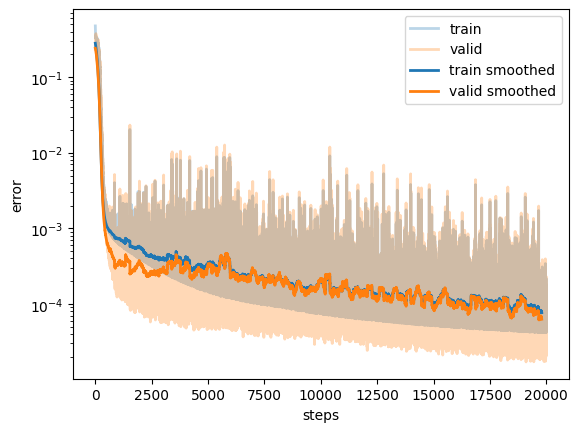

In [23]:
train_sgd_error_smooth = running_mean(train_sgd_error_lst, 200)
valid_sgd_error_smooth = running_mean(valid_sgd_error_lst, 200)

plt.plot(train_sgd_error_lst, color="C0", linewidth=2, label="train", alpha=0.3)
plt.plot(valid_sgd_error_lst, color="C1", linestyle='-', linewidth=2, label="valid", alpha=0.3)
plt.plot(train_sgd_error_smooth, color="C0", linewidth=2, label="train smoothed")
plt.plot(valid_sgd_error_smooth, color="C1", linestyle='-', linewidth=2, label="valid smoothed")
plt.yscale("log")
plt.xlabel("steps")
plt.ylabel("error")
plt.legend()

Plot the predictions together with the data. Also check out the learning progress as depicted in the PNGs written to this directory.

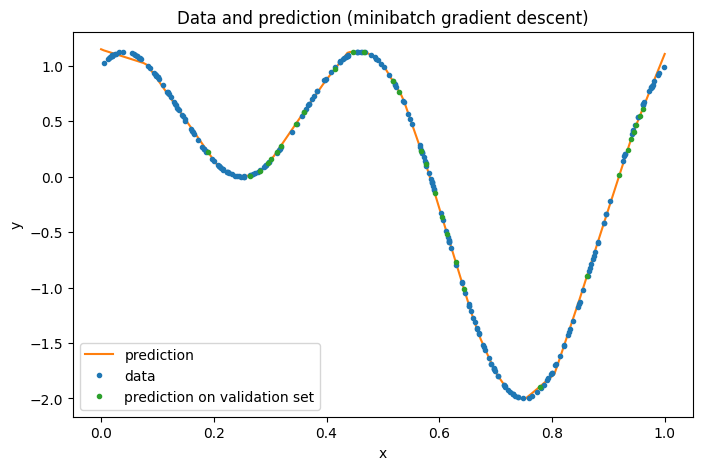

In [24]:
for i, cp in enumerate(batch_checkpoints):
    plot_predictions(
        net=cp,
        X_train=X_train,
        Y_train=Y_train,
        X_valid=X_valid,
        Y_valid=Y_valid,
        title="Data and prediction (minibatch gradient descent)",
        output_path=f"minibatch_checkpoint_{i}.png"
    )
plot_predictions(
    net=cp,
    X_train=X_train,
    Y_train=Y_train,
    X_valid=X_valid,
    Y_valid=Y_valid,
    title="Data and prediction (minibatch gradient descent)",
)

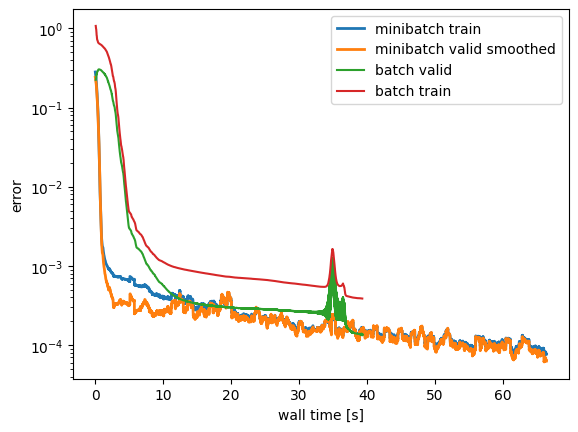

In [25]:

len_smooth = train_sgd_error_smooth.shape[0]
plt.plot(minibatch_times[:len_smooth], train_sgd_error_smooth, linewidth=2, label="minibatch train")
plt.plot(minibatch_times[:len_smooth], valid_sgd_error_smooth, linestyle='-', linewidth=2, label="minibatch valid smoothed")
plt.plot(batch_times, valid_error_lst, label="batch valid")
plt.plot(batch_times, train_error_lst, label="batch train")
plt.yscale("log")
plt.xlabel("wall time [s]")
plt.ylabel("error")
plt.legend()

### <span style="color:red">[TODO]</span> Interpretation of the learning curves (2 pts)
* Is there a difference in the training curves of batch and minibatch gradient descent with wall time on the x axis?
* How do you think would the plot with the wall time on the x axis change if the dataset was scaled up substantially?

In [26]:
### BEGIN SOLUTION
# * The minibatch gradient descent converges faster (initially) than the batch gradient descent. (0.5 point)
# * The loss of the minibatch gradient descent is noisier (due to the random sampling of the minibatches). (0.5 point)
# * Scaling the dataset up would increase the advantage of minibatch gradient descent as computing the
# gradient over the whole dataset would become prohibitively slow. (1.0 point)